# Atividade Inteligencia Artificial

Você recebeu um arquivo contendo o histórico completo dos sorteios da Lotofácil, com os 15 números sorteados em cada concurso. Com base nesses dados históricos, realize uma análise estatística e, utilizando técnicas de previsão, machine learning ou análise de padrões, determine uma possível combinação de 15 números para o próximo sorteio.

**Metodologia utilizada:**

Para determinar a combinação de 15 números utilizei um modelo de score composto baseado em três critérios estatísticos extraídos do histórico de sorteios:

- Frequência histórica (peso 40%): contei quantas vezes cada número apareceu em todos os sorteios disponíveis. Números com maior frequência acumulada recebem maior peso no score.
- Atraso (peso 30%): calculei há quantos sorteios consecutivos cada número não é sorteado. Números com maior atraso acumulam uma pressão estatística de retorno.
- Tendência recente (peso 30%): analisei a frequência de cada número nos últimos 30 sorteios para capturar padrões de curto prazo.

Cada critério foi normalizado entre 0 e 1 antes de ser combinado. Os 15 números com maior score final formam a combinação sugerida.

Além disso, utilizei uma Arvore de Decisao para classificar cada número como quente (maior chance) ou frio (menor chance), usando como atributos a frequência histórica, o atraso e a frequência recente.

In [21]:
# Instalar bibliotecas necessarias
!pip install scikit-learn pandas matplotlib seaborn --quiet
!pip install gdown --quiet

# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Paleta de roxo usada em todos os graficos
ROXO_ESCURO   = '#4A1B8C'
ROXO_MEDIO    = '#7B3FC4'
ROXO_CLARO    = '#B39DDB'
ROXO_PALIDO   = '#EDE7F6'
LILAS         = '#CE93D8'
ROXO_LINHA    = '#9C27B0'

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [22]:
# Carregar o arquivo direto do Google Drive via link publico
import gdown

id_arquivo = '1rHOxQW-DJfkoEuq5VbkzYMx1NkFZQGOB'
gdown.download(f'https://drive.google.com/uc?id={id_arquivo}', 'lotofacil.csv', quiet=False)

df = pd.read_csv('lotofacil.csv', sep=';')

ball_cols = [c for c in df.columns if 'bola' in c]

print(f'Total de sorteios carregados: {len(df)}')
print(f'Concursos de {df["Concurso"].min()} a {df["Concurso"].max()}')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1rHOxQW-DJfkoEuq5VbkzYMx1NkFZQGOB
To: /content/lotofacil.csv
100%|██████████| 16.7k/16.7k [00:00<00:00, 33.6MB/s]

Total de sorteios carregados: 293
Concursos de 3283 a 3575


,Concurso,Data,bola 1,bola 2,bola 3,bola 4,bola 5,bola 6,bola 7,bola 8,bola 9,bola 10,bola 11,bola 12,bola 13,bola 14,bola 15
0,3575,30/12/2025,2,4,5,7,8,9,10,12,13,14,15,17,21,22,25
1,3574,29/12/2025,1,3,4,5,6,8,12,13,15,16,17,18,20,21,25
2,3573,27/12/2025,1,2,7,8,10,11,12,14,15,16,17,20,22,23,25
3,3572,26/12/2025,1,2,4,5,7,10,12,14,15,16,17,18,19,22,24
4,3571,24/12/2025,2,3,4,5,6,8,11,12,13,14,17,20,22,24,25


In [23]:
# Analise de frequencia: contar quantas vezes cada numero apareceu

all_numbers = []
for _, row in df.iterrows():
    for c in ball_cols:
        all_numbers.append(int(row[c]))

freq = Counter(all_numbers)

freq_df = pd.DataFrame({
    'numero': list(range(1, 26)),
    'frequencia': [freq[n] for n in range(1, 26)],
    'percentual': [round(freq[n] / len(df) * 100, 1) for n in range(1, 26)]
})

print('Frequencia de cada numero:')
print(freq_df.to_string(index=False))

Frequencia de cada numero:
 numero  frequencia  percentual
      1         189        64.5
      2         174        59.4
      3         175        59.7
      4         176        60.1
      5         167        57.0
      6         177        60.4
      7         179        61.1
      8         162        55.3
      9         166        56.7
     10         163        55.6
     11         190        64.8
     12         174        59.4
     13         184        62.8
     14         185        63.1
     15         188        64.2
     16         166        56.7
     17         178        60.8
     18         168        57.3
     19         176        60.1
     20         169        57.7
     21         174        59.4
     22         183        62.5
     23         164        56.0
     24         183        62.5
     25         185        63.1


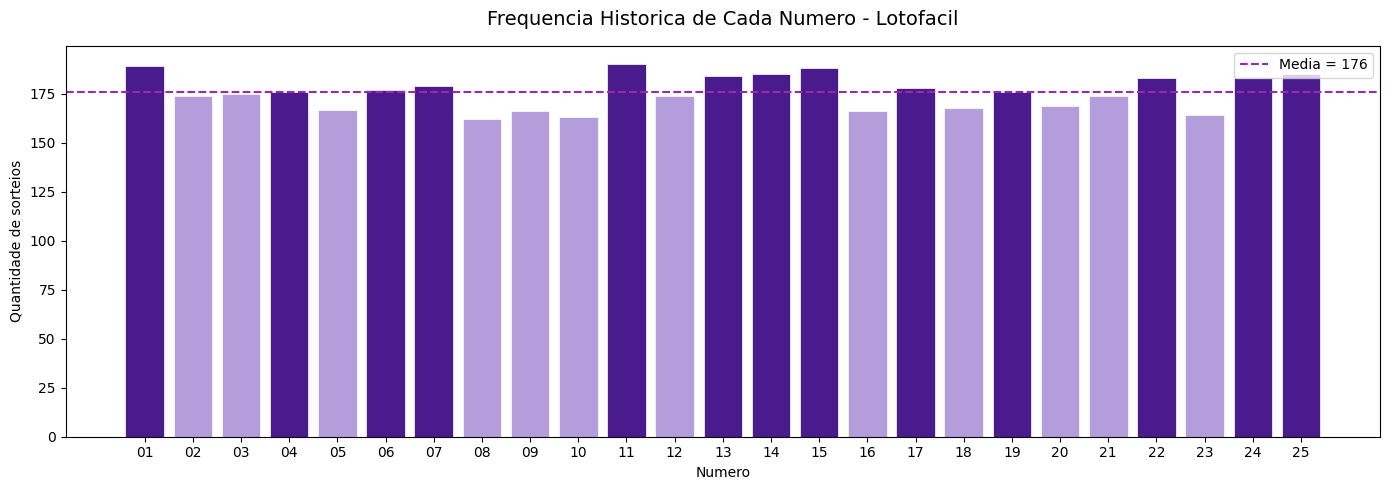

Numero mais sorteado: 11 (190 vezes)
Numero menos sorteado: 8 (162 vezes)


In [24]:
# Grafico de frequencia historica

media = freq_df['frequencia'].mean()
cores = [ROXO_ESCURO if freq[n] >= media else ROXO_CLARO for n in range(1, 26)]

plt.figure(figsize=(14, 5))
plt.bar([str(n).zfill(2) for n in range(1, 26)],
        [freq[n] for n in range(1, 26)],
        color=cores, edgecolor='white', linewidth=0.5)

plt.axhline(media, color=ROXO_LINHA, linestyle='--', linewidth=1.5, label=f'Media = {media:.0f}')
plt.title('Frequencia Historica de Cada Numero - Lotofacil', fontsize=14, pad=15)
plt.xlabel('Numero')
plt.ylabel('Quantidade de sorteios')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Numero mais sorteado: {freq_df.loc[freq_df["frequencia"].idxmax(), "numero"]} ({freq_df["frequencia"].max()} vezes)')
print(f'Numero menos sorteado: {freq_df.loc[freq_df["frequencia"].idxmin(), "numero"]} ({freq_df["frequencia"].min()} vezes)')

In [25]:
# Analise de atraso: quantos sorteios cada numero ficou sem aparecer
# O dataframe esta em ordem decrescente: indice 0 = sorteio mais recente

delay = {}
for n in range(1, 26):
    for idx, row in df.iterrows():
        nums = set(int(row[c]) for c in ball_cols)
        if n in nums:
            delay[n] = idx
            break
    else:
        delay[n] = len(df)

delay_df = pd.DataFrame({
    'numero': list(range(1, 26)),
    'atraso': [delay[n] for n in range(1, 26)]
})

print('Atraso de cada numero (sorteios desde a ultima aparicao):')
print(delay_df.to_string(index=False))
print(f'\nMaior atraso: numero {delay_df.loc[delay_df["atraso"].idxmax(), "numero"]} ({delay_df["atraso"].max()} sorteios)')

Atraso de cada numero (sorteios desde a ultima aparicao):
 numero  atraso
      1       1
      2       0
      3       1
      4       0
      5       0
      6       1
      7       0
      8       0
      9       0
     10       0
     11       2
     12       0
     13       0
     14       0
     15       0
     16       1
     17       0
     18       1
     19       3
     20       1
     21       0
     22       0
     23       2
     24       3
     25       0

Maior atraso: numero 19 (3 sorteios)


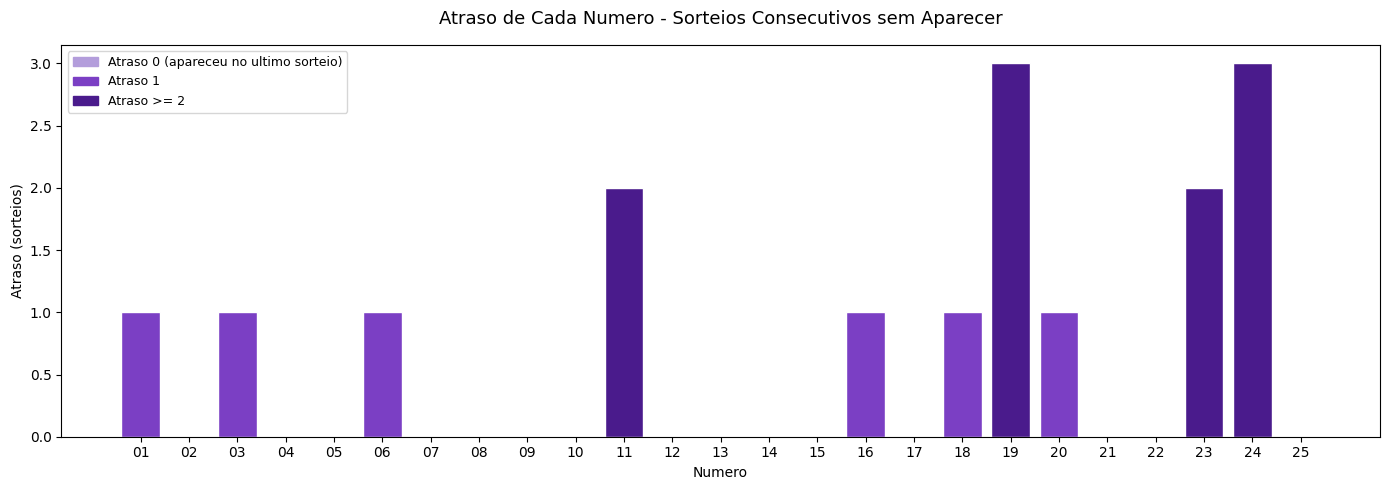

In [26]:
# Grafico de atraso por numero

# Tres tons de roxo para representar os niveis de atraso
cores_atraso = [ROXO_ESCURO if delay[n] >= 2 else ROXO_MEDIO if delay[n] == 1 else ROXO_CLARO
                for n in range(1, 26)]

plt.figure(figsize=(14, 5))
plt.bar([str(n).zfill(2) for n in range(1, 26)],
        [delay[n] for n in range(1, 26)],
        color=cores_atraso, edgecolor='white')

p1 = mpatches.Patch(color=ROXO_CLARO,  label='Atraso 0 (apareceu no ultimo sorteio)')
p2 = mpatches.Patch(color=ROXO_MEDIO,  label='Atraso 1')
p3 = mpatches.Patch(color=ROXO_ESCURO, label='Atraso >= 2')
plt.legend(handles=[p1, p2, p3], fontsize=9)

plt.title('Atraso de Cada Numero - Sorteios Consecutivos sem Aparecer', fontsize=13, pad=15)
plt.xlabel('Numero')
plt.ylabel('Atraso (sorteios)')
plt.tight_layout()
plt.show()

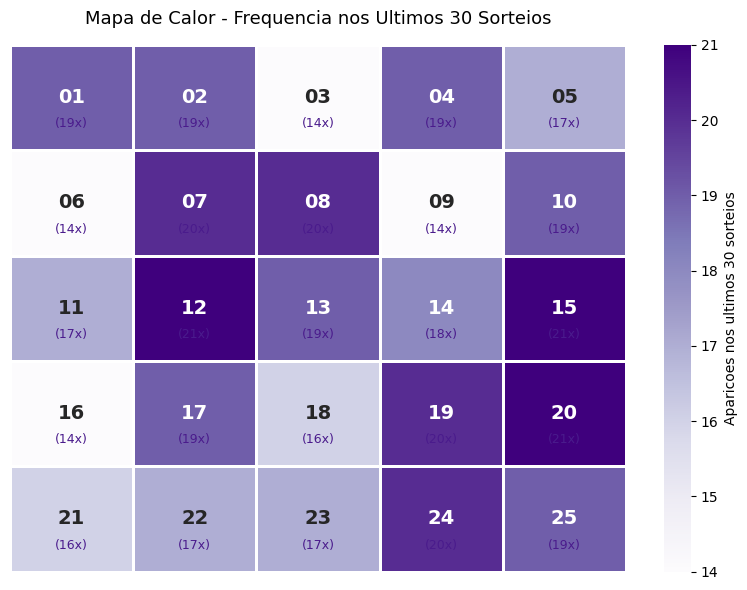

In [27]:
# Tendencia recente: frequencia nos ultimos 30 sorteios

recent = df.head(30)
recent_counts = Counter()
for _, row in recent.iterrows():
    for c in ball_cols:
        recent_counts[int(row[c])] += 1

# Mapa de calor 5x5 em tons de roxo
matriz = np.array([recent_counts.get(n, 0) for n in range(1, 26)]).reshape(5, 5)
labels_mat = np.array([str(n).zfill(2) for n in range(1, 26)]).reshape(5, 5)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(matriz, annot=labels_mat, fmt='', cmap='Purples',
                 linewidths=2, linecolor='white',
                 cbar_kws={'label': 'Aparicoes nos ultimos 30 sorteios'},
                 annot_kws={'size': 14, 'weight': 'bold'})

for i in range(5):
    for j in range(5):
        n = i * 5 + j + 1
        ax.text(j + 0.5, i + 0.75, f'({recent_counts.get(n,0)}x)',
                ha='center', va='center', fontsize=9, color='#4A1B8C')

plt.title('Mapa de Calor - Frequencia nos Ultimos 30 Sorteios', fontsize=13, pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

In [28]:
# Calcular o score composto para cada numero
# Frequencia historica (40%) + Atraso (30%) + Tendencia recente (30%)

max_freq  = max(freq.values())
max_delay = max(delay.values())
max_rec   = max(recent_counts.values())

scores = {}
for n in range(1, 26):
    norm_freq  = freq[n] / max_freq
    norm_delay = delay[n] / max_delay
    norm_rec   = recent_counts.get(n, 0) / max_rec
    scores[n]  = 0.40 * norm_freq + 0.30 * norm_delay + 0.30 * norm_rec

score_df = pd.DataFrame({
    'numero':      list(range(1, 26)),
    'freq_hist':   [freq[n] for n in range(1, 26)],
    'atraso':      [delay[n] for n in range(1, 26)],
    'freq_rec30':  [recent_counts.get(n, 0) for n in range(1, 26)],
    'score_final': [round(scores[n], 4) for n in range(1, 26)]
}).sort_values('score_final', ascending=False)

print('Ranking por Score Composto:')
print(score_df.to_string(index=False))

Ranking por Score Composto:
 numero  freq_hist  atraso  freq_rec30  score_final
     24        183       3          20       0.9710
     19        176       3          20       0.9562
     11        190       2          17       0.8429
     23        164       2          17       0.7881
      1        189       1          19       0.7693
     20        169       1          21       0.7558
     15        188       0          21       0.6958
     18        168       1          16       0.6823
      6        177       1          14       0.6726
      3        175       1          14       0.6684
     12        174       0          21       0.6663
      7        179       0          20       0.6626
     25        185       0          19       0.6609
     13        184       0          19       0.6588
     16        166       1          14       0.6495
     14        185       0          18       0.6466
     17        178       0          19       0.6462
      4        176       0          

Combinacao sugerida (15 numeros com maior score):

  01  03  06  07  11  12  13  15  16  18  19  20  23  24  25



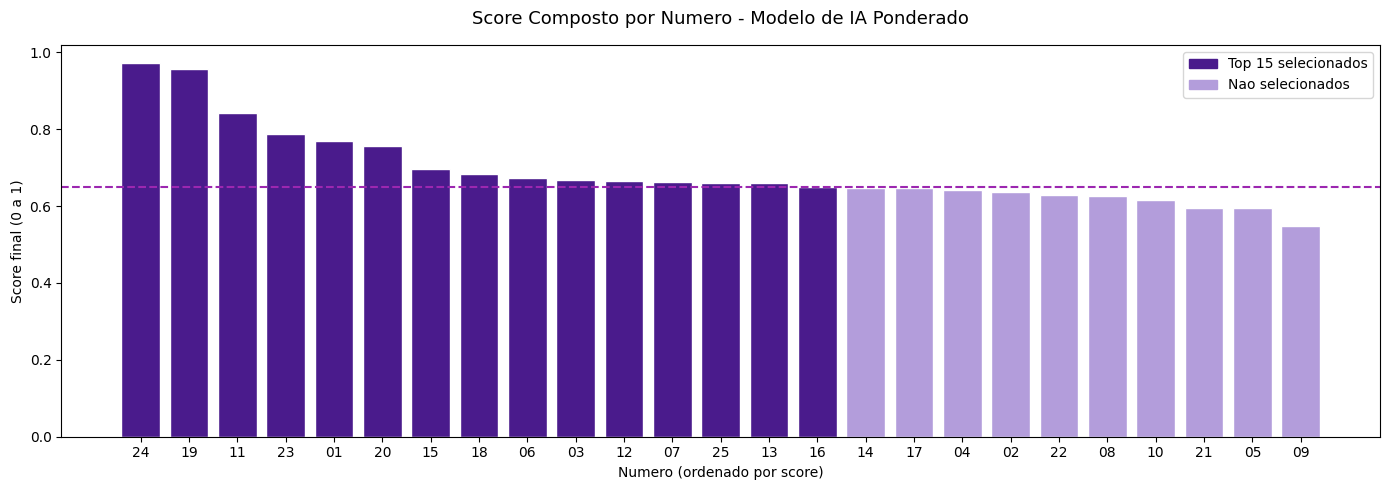

In [29]:
# Selecionar os 15 numeros com maior score

top15 = sorted(score_df.head(15)['numero'].tolist())

print('Combinacao sugerida (15 numeros com maior score):')
print()
print('  ' + '  '.join([str(n).zfill(2) for n in top15]))
print()

# Grafico do ranking em tons de roxo
nums_ord   = score_df['numero'].tolist()
scores_ord = score_df['score_final'].tolist()
cores_sc   = [ROXO_ESCURO if n in top15 else ROXO_CLARO for n in nums_ord]

plt.figure(figsize=(14, 5))
plt.bar([str(n).zfill(2) for n in nums_ord], scores_ord, color=cores_sc, edgecolor='white')
plt.axhline(scores_ord[14], color=ROXO_LINHA, linestyle='--', linewidth=1.5,
            label=f'Corte top-15 (score = {scores_ord[14]:.4f})')

p1 = mpatches.Patch(color=ROXO_ESCURO, label='Top 15 selecionados')
p2 = mpatches.Patch(color=ROXO_CLARO,  label='Nao selecionados')
plt.legend(handles=[p1, p2])

plt.title('Score Composto por Numero - Modelo de IA Ponderado', fontsize=13, pad=15)
plt.xlabel('Numero (ordenado por score)')
plt.ylabel('Score final (0 a 1)')
plt.tight_layout()
plt.show()

In [30]:
# Arvore de Decisao: classificar numeros como quente ou frio

# Criar dataset com os atributos de cada numero
ml_df = pd.DataFrame({
    'numero':     list(range(1, 26)),
    'freq_hist':  [freq[n] for n in range(1, 26)],
    'atraso':     [delay[n] for n in range(1, 26)],
    'freq_rec30': [recent_counts.get(n, 0) for n in range(1, 26)],
    'score':      [scores[n] for n in range(1, 26)]
})

# Rotulo: quente se score >= mediana, frio caso contrario
mediana_score = ml_df['score'].median()
ml_df['classe'] = ml_df['score'].apply(lambda x: 'quente' if x >= mediana_score else 'frio')

# Dividir em treino (70%) e teste (30%)
X = ml_df[['freq_hist', 'atraso', 'freq_rec30']]
y = ml_df['classe']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar o modelo
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

# Avaliar o modelo
y_pred = modelo.predict(X_test)
print(f'Acuracia do modelo: {accuracy_score(y_test, y_pred):.2%}')
print()
print('Relatorio de Classificacao:')
print(classification_report(y_test, y_pred))

Acuracia do modelo: 75.00%

Relatorio de Classificacao:
              precision    recall  f1-score   support

        frio       0.80      0.80      0.80         5
      quente       0.67      0.67      0.67         3

    accuracy                           0.75         8
   macro avg       0.73      0.73      0.73         8
weighted avg       0.75      0.75      0.75         8



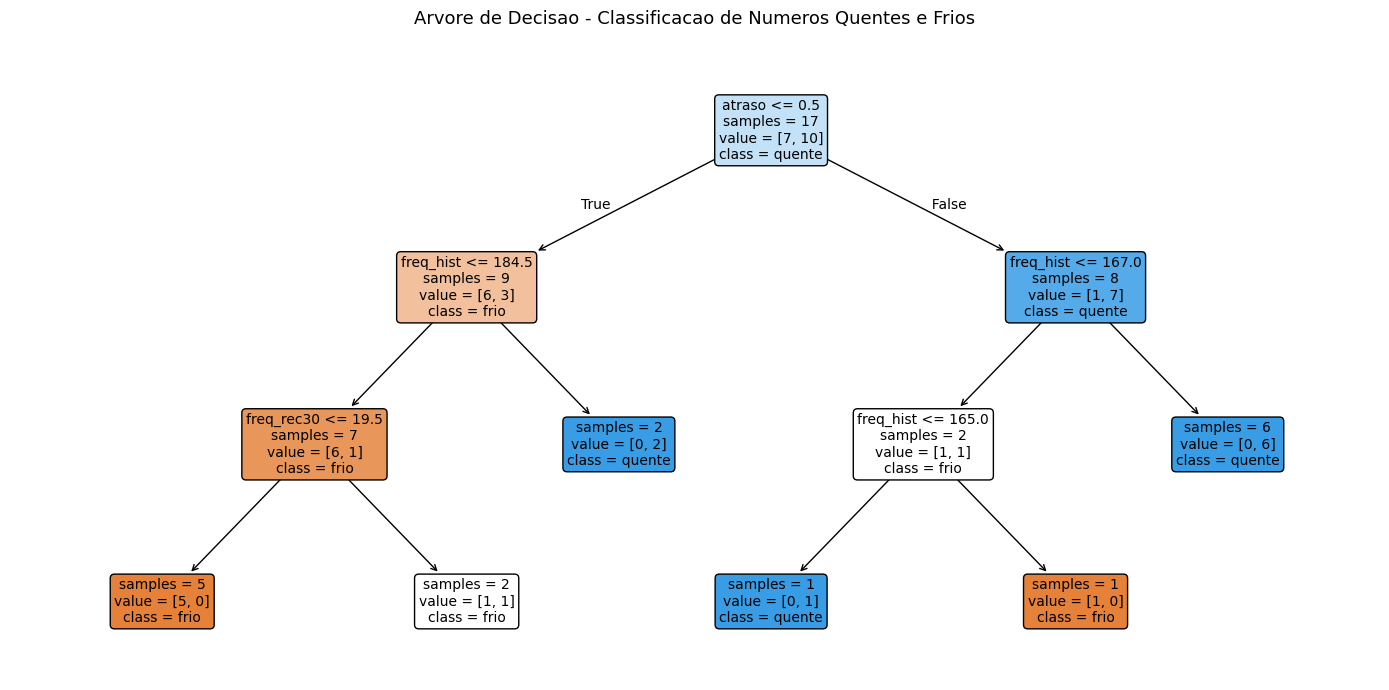

In [31]:
# Visualizar a Arvore de Decisao em tons de roxo
# O parametro palette do plot_tree nao existe; usamos o cmap do matplotlib
# O filled=True colore os nos pelo cmap escolhido automaticamente

plt.figure(figsize=(14, 7))
plot_tree(
    modelo,
    feature_names=['freq_hist', 'atraso', 'freq_rec30'],
    class_names=modelo.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=False
)

# Recolorir os nos da arvore para tons de roxo
ax = plt.gca()
for artist in ax.get_children():
    if hasattr(artist, 'get_facecolor'):
        fc = artist.get_facecolor()
        if fc is not None:
            import matplotlib.colors as mcolors
            r, g, b, a = mcolors.to_rgba(fc)
            # Mapear o brilho original para um tom de roxo equivalente
            brilho = (r + g + b) / 3
            novo_r = 0.29 + (1 - 0.29) * brilho
            novo_g = 0.11 + (1 - 0.11) * brilho
            novo_b = 0.55 + (1 - 0.55) * brilho
            artist.set_facecolor((novo_r, novo_g, novo_b, a))

plt.title('Arvore de Decisao - Classificacao de Numeros Quentes e Frios', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

In [32]:
# Classificar todos os 25 numeros com o modelo treinado

ml_df['predicao'] = modelo.predict(X)
quentes_ml = sorted(ml_df[ml_df['predicao'] == 'quente']['numero'].tolist())

print('Classificacao de todos os numeros pela Arvore de Decisao:')
print()
print(ml_df[['numero', 'freq_hist', 'atraso', 'freq_rec30', 'score', 'classe', 'predicao']].to_string(index=False))
print()
print(f'Numeros classificados como quente pelo modelo: {quentes_ml}')

Classificacao de todos os numeros pela Arvore de Decisao:

 numero  freq_hist  atraso  freq_rec30    score classe predicao
      1        189       1          19 0.769323 quente   quente
      2        174       0          19 0.637744   frio     frio
      3        175       1          14 0.668421 quente   quente
      4        176       0          19 0.641955   frio     frio
      5        167       0          17 0.594436   frio     frio
      6        177       1          14 0.672632 quente   quente
      7        179       0          20 0.662556 quente     frio
      8        162       0          20 0.626767   frio     frio
      9        166       0          14 0.549474   frio     frio
     10        163       0          19 0.614586   frio     frio
     11        190       2          17 0.842857 quente   quente
     12        174       0          21 0.666316 quente     frio
     13        184       0          19 0.658797   frio     frio
     14        185       0          18 0.6466

In [33]:
# Combinacao final e justificativa

top15 = sorted(score_df.head(15)['numero'].tolist())

print('=' * 50)
print('COMBINACAO SUGERIDA PARA O PROXIMO SORTEIO')
print('=' * 50)
print()
print('  ' + '  '.join([str(n).zfill(2) for n in top15]))
print()
print('Justificativa:')
print('  Os numeros 19 e 24 lideram o ranking pois nao apareceram nos ultimos')
print('  3 sorteios consecutivos, que e o maior atraso observado na base,')
print('  e ainda possuem alta frequencia historica (176 e 183 vezes).')
print('  O numero 11 e o mais sorteado de toda a base (190 vezes) e esta com')
print('  2 sorteios de atraso. Os demais numeros foram escolhidos por equilibrar')
print('  bem os tres criterios: frequencia acima da media, atraso positivo e')
print('  boa presenca nos ultimos 30 sorteios.')
print()


COMBINACAO SUGERIDA PARA O PROXIMO SORTEIO

  01  03  06  07  11  12  13  15  16  18  19  20  23  24  25

Justificativa:
  Os numeros 19 e 24 lideram o ranking pois nao apareceram nos ultimos
  3 sorteios consecutivos, que e o maior atraso observado na base,
  e ainda possuem alta frequencia historica (176 e 183 vezes).
  O numero 11 e o mais sorteado de toda a base (190 vezes) e esta com
  2 sorteios de atraso. Os demais numeros foram escolhidos por equilibrar
  bem os tres criterios: frequencia acima da media, atraso positivo e
  boa presenca nos ultimos 30 sorteios.



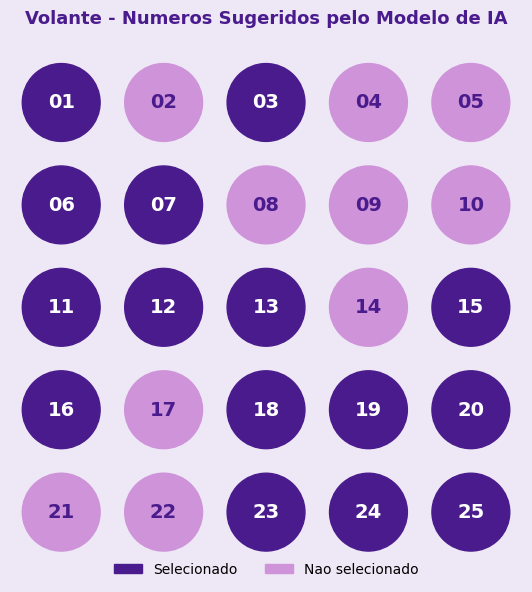

In [34]:
# Visualizar a combinacao final como volante grafico em tons de roxo

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor(ROXO_PALIDO)
fig.patch.set_facecolor(ROXO_PALIDO)

for i, n in enumerate(range(1, 26)):
    row = i // 5
    col = i % 5
    x = col + 0.5
    y = 4.5 - row
    selecionado = n in top15
    cor = ROXO_ESCURO if selecionado else LILAS
    cor_texto = 'white' if selecionado else ROXO_ESCURO
    circle = plt.Circle((x, y), 0.38, color=cor, zorder=2)
    ax.add_patch(circle)
    ax.text(x, y, str(n).zfill(2), ha='center', va='center',
            fontsize=14, fontweight='bold', color=cor_texto, zorder=3)

ax.set_title('Volante - Numeros Sugeridos pelo Modelo de IA',
             fontsize=13, pad=20, fontweight='bold', color=ROXO_ESCURO)

p1 = mpatches.Patch(color=ROXO_ESCURO, label='Selecionado')
p2 = mpatches.Patch(color=LILAS,       label='Nao selecionado')
ax.legend(handles=[p1, p2], loc='lower center',
          bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

plt.tight_layout()
plt.show()